In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# Cài đặt các thư viện cần thiết cho YOLOv11 và Roboflow
!pip install -q ultralytics roboflow

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.2/41.2 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 33.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 249.2/249.2 kB 27.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 16.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 67.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 128.7 MB/s eta 0:00:00


In [3]:
# ============================================================
# KHAI BÁO THƯ VIỆN
# ============================================================

import os
import yaml
import cv2
import random
import numpy as np
import pandas as pd
from pathlib import Path
from PIL import Image as PILImage
from IPython.display import Image, display
import tqdm
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import seaborn as sns
import torch
from ultralytics import YOLO
from roboflow import Roboflow
import seaborn as sns


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [4]:
rf = Roboflow(api_key="kaUQUC7s0NNUJ2AiPlBE")
project = rf.workspace("quanh").project("ki-tu-bien-so")
version = project.version(9)
dataset = version.download("yolo26")


loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Kí-tự-Biển-số-9 in yolo26:: 100%|██████████| 6307/6307 [00:01<00:00, 3546.73it/s]


In [5]:
DATASET_PATH = dataset.location
yaml_path = os.path.join(DATASET_PATH, "data.yaml")

print(f"New dataset path: {DATASET_PATH}")
print(f"New YAML config path: {yaml_path}")

with open(yaml_path, 'r') as f:
    new_data_config = yaml.safe_load(f)
print("Content of new data.yaml:")
display(new_data_config)

New dataset path: /content/Kí-tự-Biển-số-9
New YAML config path: /content/Kí-tự-Biển-số-9/data.yaml
Content of new data.yaml:


{'train': '../train/images',
 'val': '../valid/images',
 'test': '../test/images',
 'nc': 31,
 'names': ['0',
  '1',
  '2',
  '3',
  '4',
  '5',
  '6',
  '7',
  '8',
  '9',
  'A',
  'B',
  'C',
  'D',
  'E',
  'F',
  'G',
  'H',
  'K',
  'L',
  'M',
  'N',
  'P',
  'R',
  'S',
  'T',
  'U',
  'V',
  'X',
  'Y',
  'Z'],
 'roboflow': {'workspace': 'quanh',
  'project': 'ki-tu-bien-so',
  'version': 9,
  'license': 'CC BY 4.0',
  'url': 'https://universe.roboflow.com/quanh/ki-tu-bien-so/dataset/9'}}

EDA

Số lượng ảnh: Train=2607, Val=267, Test=277




Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.



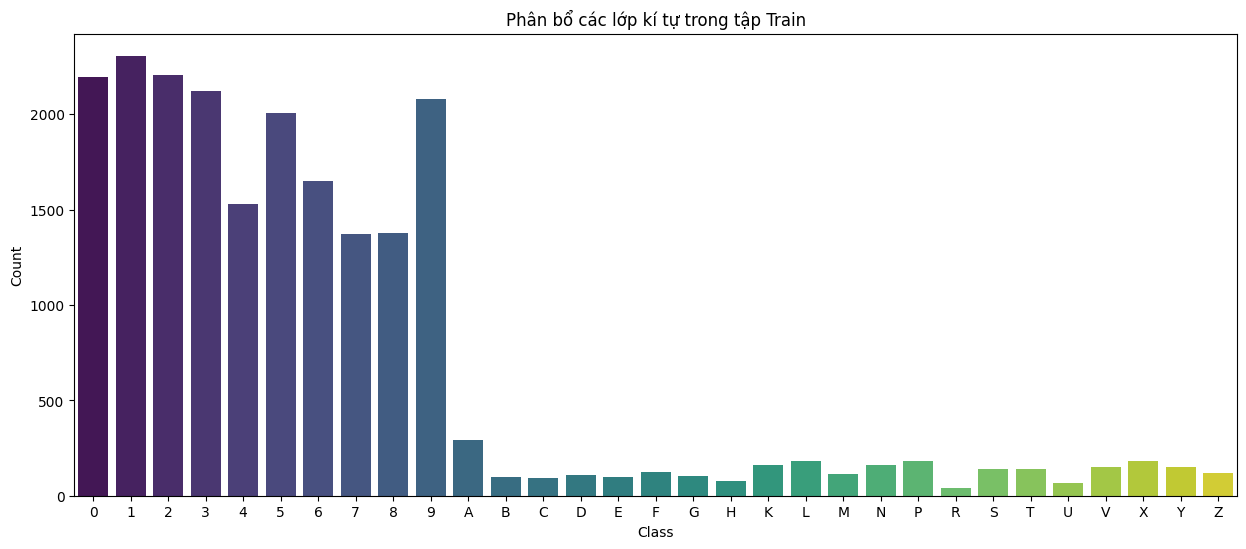

In [6]:
def get_stats(subset):
    path = os.path.join(DATASET_PATH, subset, 'labels')
    class_counts = {}
    if not os.path.exists(path):
        return class_counts

    label_files = [f for f in os.listdir(path) if f.endswith('.txt')]
    for file in label_files:
        with open(os.path.join(path, file), 'r') as f:
            for line in f:
                cls = int(line.split()[0])
                class_counts[cls] = class_counts.get(cls, 0) + 1
    return class_counts, len(label_files)

train_counts, n_train = get_stats('train')
val_counts, n_val = get_stats('valid')
test_counts, n_test = get_stats('test')

print(f"Số lượng ảnh: Train={n_train}, Val={n_val}, Test={n_test}")

# Chuyển đổi tên class từ data.yaml
class_names = new_data_config['names']
df_stats = pd.DataFrame([{'Class': class_names[k], 'Count': v} for k, v in train_counts.items()])
df_stats = df_stats.sort_values(by='Class')

plt.figure(figsize=(15, 6))
sns.barplot(data=df_stats, x='Class', y='Count', palette='viridis')
plt.title("Phân bổ các lớp kí tự trong tập Train")
plt.xticks(rotation=0)
plt.show()

### Trực quan hóa mẫu ảnh kí tự
Hiển thị một số ảnh ngẫu nhiên từ tập huấn luyện kèm theo khung bao (bounding box).

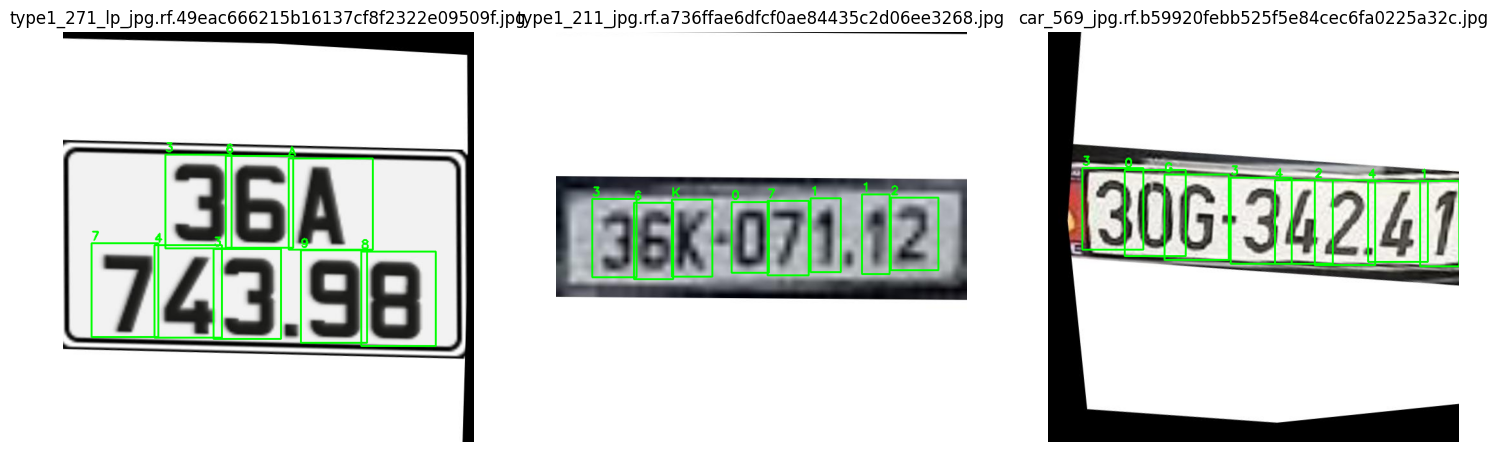

In [7]:
def plot_random_samples(subset='train', num=3):
    img_dir = os.path.join(DATASET_PATH, subset, 'images')
    lbl_dir = os.path.join(DATASET_PATH, subset, 'labels')
    images = os.listdir(img_dir)
    samples = random.sample(images, num)

    fig, axes = plt.subplots(1, num, figsize=(18, 6))
    for i, img_name in enumerate(samples):
        img_path = os.path.join(img_dir, img_name)
        lbl_path = os.path.join(lbl_dir, img_name.replace('.jpg', '.txt').replace('.png', '.txt'))

        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        h, w, _ = img.shape

        if os.path.exists(lbl_path):
            with open(lbl_path, 'r') as f:
                for line in f:
                    cls, x, y, bw, bh = map(float, line.split())
                    x1, y1 = int((x - bw/2) * w), int((y - bh/2) * h)
                    x2, y2 = int((x + bw/2) * w), int((y + bh/2) * h)
                    cv2.rectangle(img, (x1, y1), (x2, y2), (0, 255, 0), 2)
                    cv2.putText(img, class_names[int(cls)], (x1, y1-5), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 2)

        axes[i].imshow(img)
        axes[i].axis('off')
        axes[i].set_title(img_name)
    plt.show()

plot_random_samples()

In [8]:
# 1. Cấu hình đường dẫn lưu trữ cho mô hình đọc kí tự
save_dir_char = '/content/drive/MyDrive/YOLO26_Char'

# 2. Khởi tạo mô hình YOLOv26n
model_char = YOLO("yolo26n.pt")

# 3. Huấn luyện với dataset Roboflow
results = model_char.train(
    data=yaml_path,     # Đường dẫn tới data.yaml của dataset ki-tu-bien-so
    epochs=100,         # Số epoch huấn luyện
    imgsz=640,          # Kích thước ảnh đầu vào
    batch=16,           # Điều chỉnh batch size phù hợp với GPU
    patience=20,        # Dừng sớm nếu không cải thiện sau 20 epoch
    project=save_dir_char,
    name="char_recognition",
    exist_ok=True,
    device=0,
    optimizer='auto'
)

print("Quá trình huấn luyện mô hình đọc kí tự đã hoàn tất!")

Ultralytics 8.4.60 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/Kí-tự-Biển-số-9/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=char_recognition, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, 

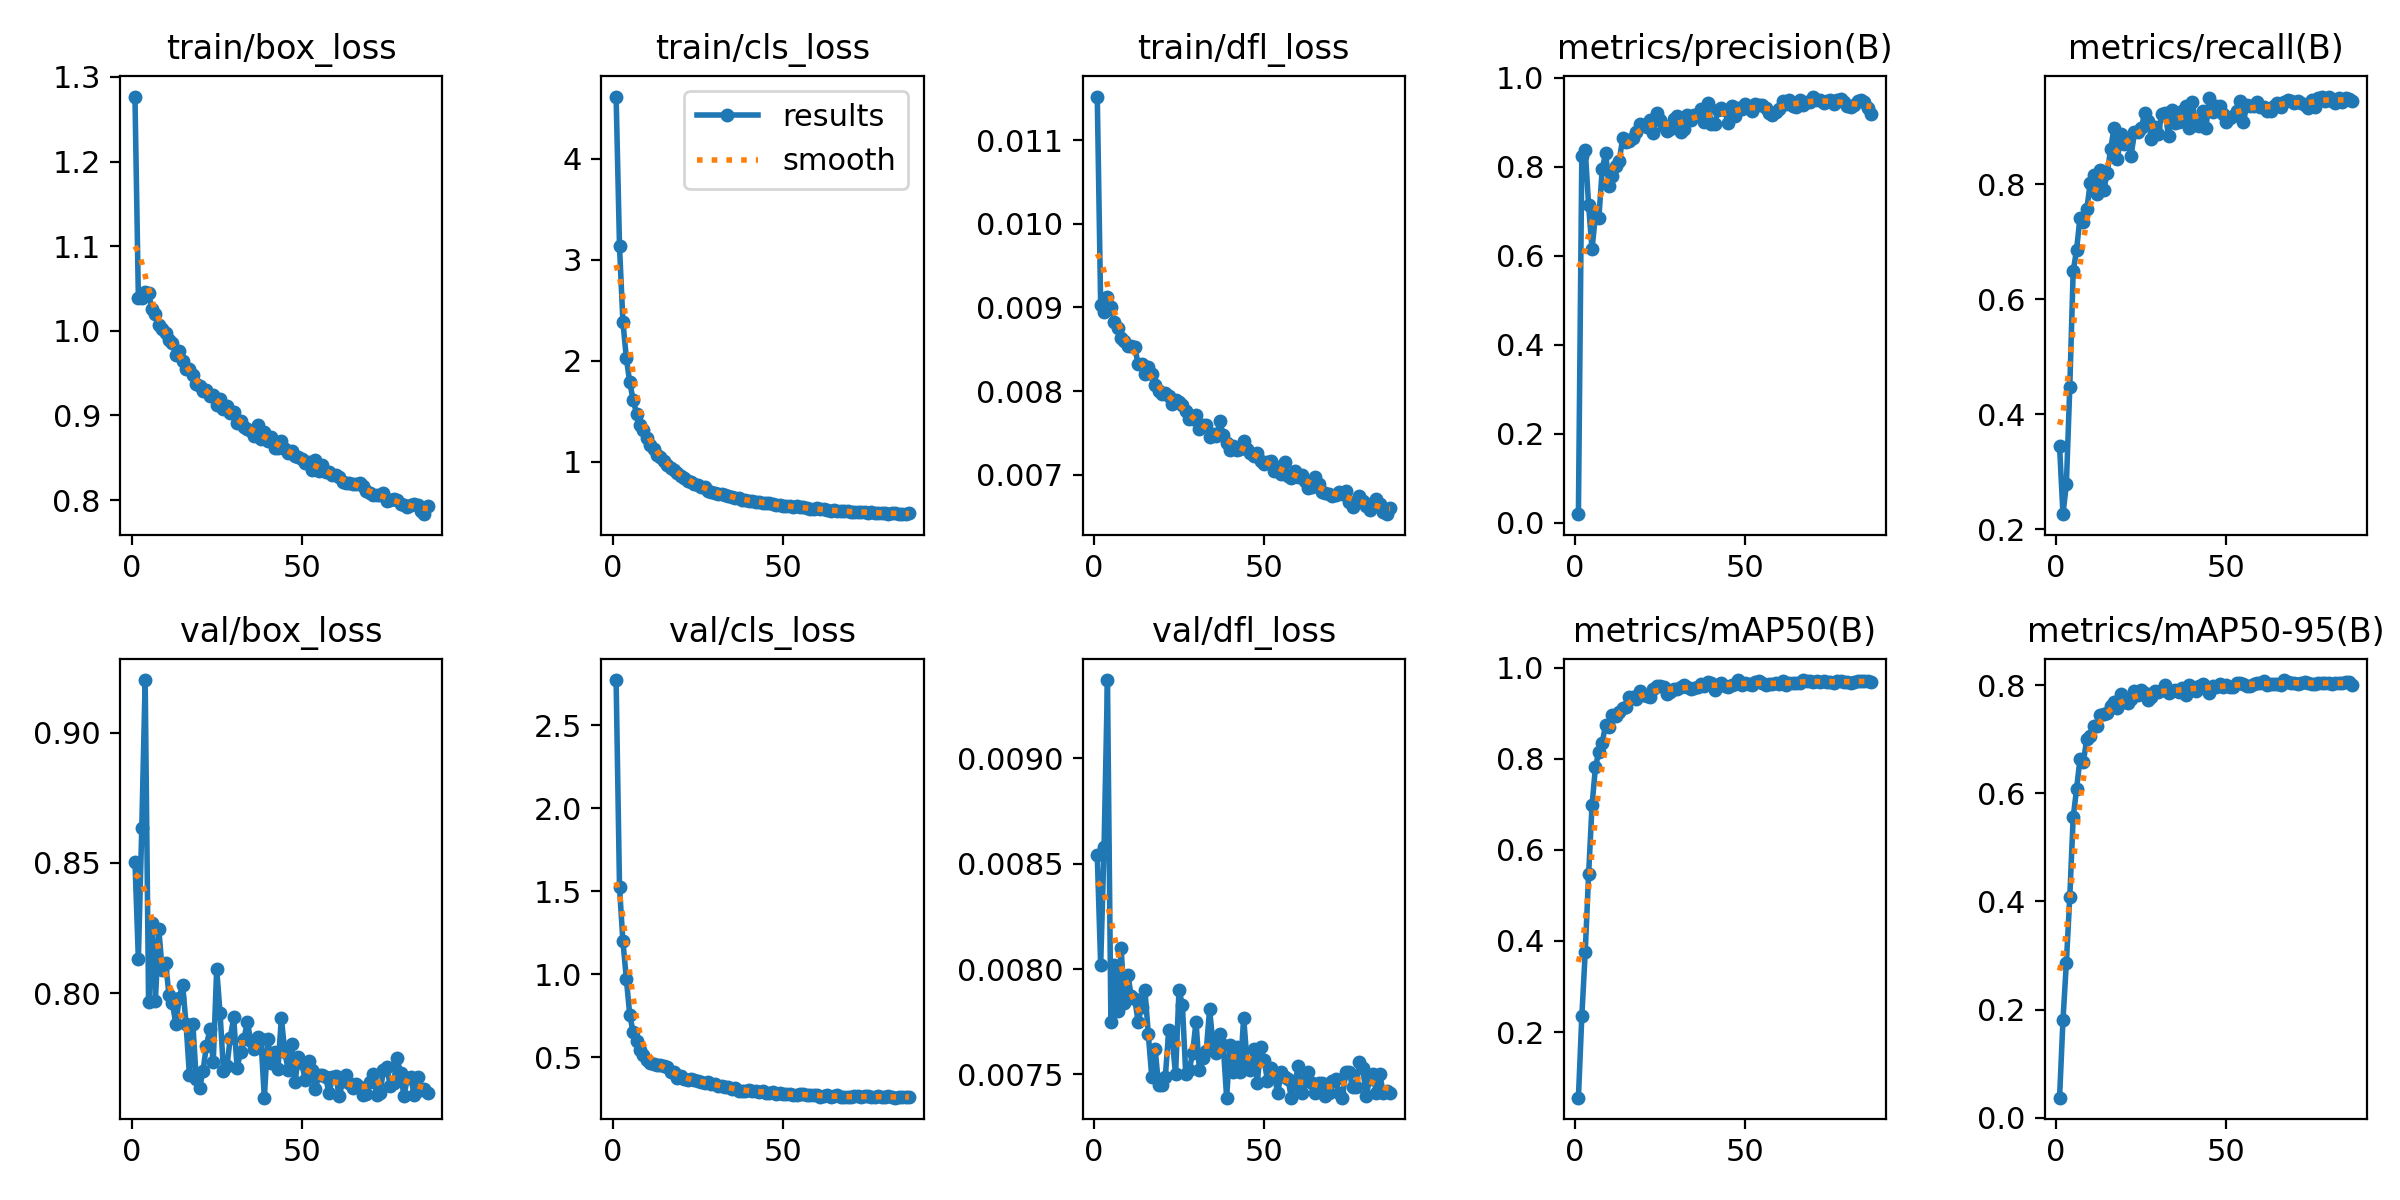

In [9]:
# Hiển thị kết quả huấn luyện mới

results_img_path = os.path.join('/content/drive/MyDrive/YOLO26_Char/char_recognition', 'results.png')
display(PILImage.open(results_img_path))

=== MA TRẬN NHẦM LẪN (CONFUSION MATRIX) - CHAR RECOGNITION ===


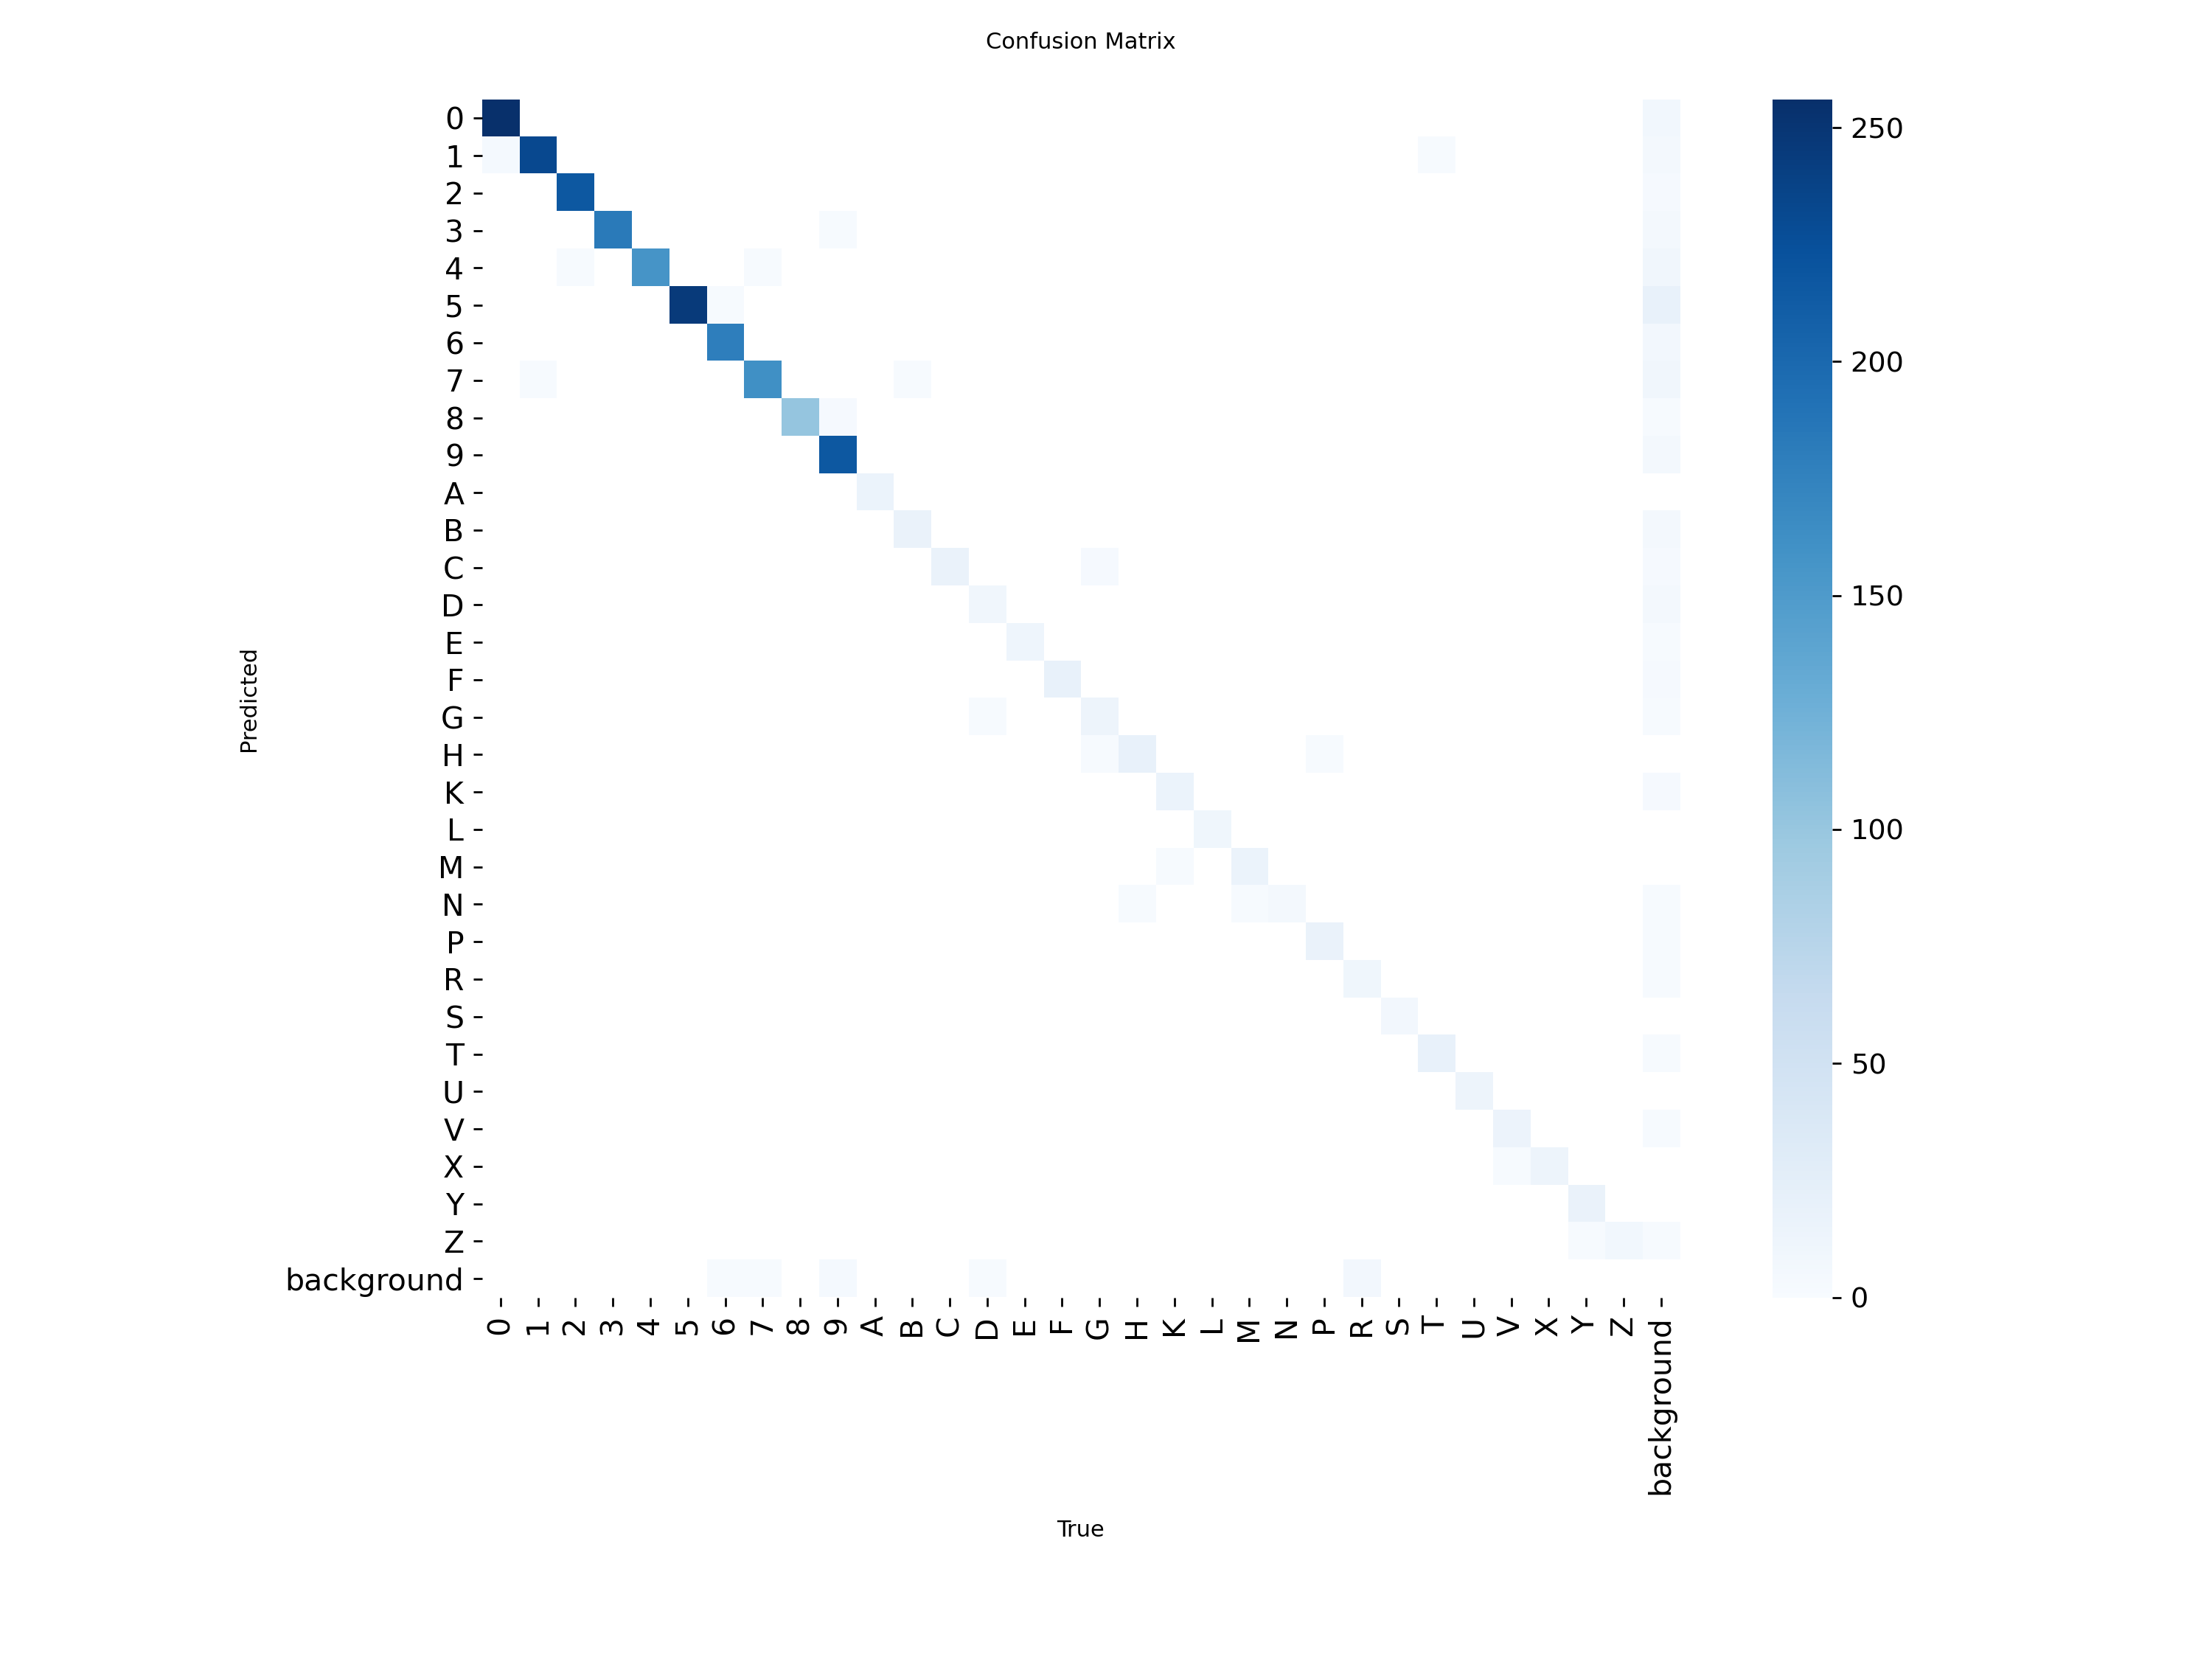

In [10]:
# Xác định đường dẫn file ma trận nhầm lẫn cho mô hình đọc kí tự
cm_img_path = os.path.join('/content/drive/MyDrive/YOLO26_Char/char_recognition', 'confusion_matrix.png')
img = PILImage.open(cm_img_path)
print("=== MA TRẬN NHẦM LẪN (CONFUSION MATRIX) - CHAR RECOGNITION ===")
display(img)